In [ ]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/cases_train2 (12).xlsx')
df['Оценка'] = df['Оценка'].round().astype('Int64')
df_test_cases = pd.read_excel('/content/Test1_2 (3).xlsx')
df_test_cases['Оценка'] = df_test_cases['Оценка'].round().astype('Int64')
#df = pd.read_excel("/content/good table.xlsx")
df.head(100)


,Кейс,Решение,Решение кейса,ЦА,Проработка решения,Финансовая модель и метрики,Анализ рисков,Доказательства,Оценка
0,1,1,Я выбрал отрасль туризма и гостиничного бизнес...,1,1,1,1,1,1
1,1,2,Я выбрал для разработки отраслевого решения сф...,2,2,2,2,2,2
2,1,4,"Я выбрал отрасль образования, а именно сегмент...",2,4,4,3,3,3
3,1,5,Я выбрал отрасль розничной торговли продуктами...,1,3,2,2,1,2
4,1,6,Я выбрал для отраслевого решения сферу гостини...,3,2,2,2,3,2
...,...,...,...,...,...,...,...,...,...
95,1,97,Я выбрал отрасль грузоперевозок. Целевая аудит...,2,2,4,3,1,2
96,1,98,Я выбрал отрасль ремонта техники. Целевая ауди...,3,2,3,2,2,2
97,1,99,Я выбрал отрасль такси. Целевая аудитория: вод...,1,1,4,3,1,2
98,1,100,Я выбрал отрасль ремонта квартир. Целевая ауди...,3,3,3,2,2,3


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from transformers import BertTokenizer, BertModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


In [ ]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    mean_absolute_error,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
df["Кейс"].value_counts()

,count
Кейс,
1,454
8,128
2,121
4,120
6,120
5,120
10,120
9,120
3,118


In [ ]:
df["Доказательства"].value_counts()

,count
Доказательства,
4,394
2,323
3,320
5,289
1,206
6,1


In [ ]:
df["Оценка"].value_counts()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
class BertClassifier(nn.Module):
  def __init__(self, num_classes, model_name='bert-base-multilingual-cased'):
    super(BertClassifier, self).__init__()
    self.bert = BertModel.from_pretrained(model_name)
    for param in self.bert.parameters():
      param.requires_grad=False
    for layer in self.bert.encoder.layer[-2:]:
      for param in layer.parameters():
        param.requires_grad=True
    self.classifier = nn.Sequential(nn.Dropout(0.3),
                                    nn.Linear(self.bert.config.hidden_size, 256),
                                    nn.ReLU(),
                                    nn.Dropout(0.2),
                                    nn.Linear(256, num_classes)
    )
  def forward(self, input_ids, attention_mask):
    with torch.no_grad():
      outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
      cls = outputs.last_hidden_state[:, 0, :]
    logits = self.classifier(cls)
    return logits

In [ ]:
tokenizer= BertTokenizer.from_pretrained("bert-base-multilingual-cased")
model = BertClassifier(num_classes=5)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=2e-4)
criterion = nn.CrossEntropyLoss()


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def train(loader):
    total_loss = 0
    model.train()
    for batch in loader:
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)
      optimizer.zero_grad()
      outputs = model(input_ids=input_ids, attention_mask=attention_mask)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    return total_loss / len(loader)


In [ ]:
def evals(loader):
    model.eval()
    loss_lst = []
    predictions = []
    total = 0
    correct = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            loss_lst.append(loss.item())
            correct += (preds == labels).sum().item()
            total += len(labels)
            predictions.extend(preds.cpu().numpy())

    return np.mean(loss_lst), correct / total, np.array(predictions)

In [ ]:
def predicts(texts, model, tokenizer, device, label_encoder=None, max_len=128):
  model.eval()
  predictions = []
  with torch.no_grad():
    for text in texts:
      encoding = tokenizer(text, truncation=True, padding="max_length", max_length=max_len, return_tensors="pt")
      input_ids = encoding["input_ids"].to(device)
      attention_mask = encoding["attention_mask"].to(device)
      outputs = model(input_ids=input_ids, attention_mask=attention_mask)
      probs = torch.softmax(outputs, dim=1)
      pred = torch.argmax(probs, dim=1)
      predictions.append(pred.cpu().numpy()[0])
  return np.array(predictions)

In [ ]:
X_text_audience = df['Решение кейса'].fillna('').values
y_audience = (df['ЦА'].values - 1).astype("int64")

X_train_text_audience, X_test_text_audience, y_train_audience, y_test_audience = train_test_split(
    X_text_audience, y_audience, test_size=0.2, random_state=42, stratify=y_audience
)
X_text_dataset_audience = TextDataset(X_train_text_audience, y_train_audience, tokenizer)
X_val_dataset_audience = TextDataset(X_test_text_audience, y_test_audience, tokenizer)
X_text_dataloader_audience = DataLoader(X_text_dataset_audience, batch_size=16, shuffle=True)
X_val_dataloader_audience = DataLoader(X_val_dataset_audience, batch_size=16, shuffle=False)
model_audience = BertClassifier(num_classes=5)
model_audience.to(device)
optimizer_audience = torch.optim.AdamW(model_audience.classifier.parameters(), lr=2e-4)
criterion_audience = nn.CrossEntropyLoss()
model = model_audience
model.to(device)
optimizer = optimizer_audience
criterion = criterion_audience


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
best_loss_audience = float("inf")
loss_all = 0
loss_val = 0
train_losses_audience = []
val_losses_audience = []
for epoch in range(30):
  train_loss = train(X_text_dataloader_audience)
  loss_all += train_loss
  train_losses_audience.append(train_loss)
  print(epoch)
  print("train_loss=", train_loss)
  val_loss, val_acc, predictions = evals(X_val_dataloader_audience)
  loss_val+=val_loss
  val_losses_audience.append(val_loss)
  print("val_loss=", val_loss)
  print("val_acc=", val_acc)
  if val_loss <= best_loss_audience:
    best_loss_audience = val_loss
    torch.save(model_audience.state_dict(), "best_model_audience.pt")
print("best_val_loss", best_loss_audience)
print("avg_train", loss_all / 10)
print("avg_val", loss_val / 10)

0
train_loss= 1.5812851654855828
val_loss= 1.5327658653259277
val_acc= 0.2335958005249344
1
train_loss= 1.527059191151669
val_loss= 1.4672512859106064
val_acc= 0.35170603674540685
2
train_loss= 1.476283073425293
val_loss= 1.4266778876384099
val_acc= 0.4146981627296588
3
train_loss= 1.4402105256130822
val_loss= 1.3901167859633763
val_acc= 0.4094488188976378
4
train_loss= 1.4035460296430087
val_loss= 1.363988866408666
val_acc= 0.4068241469816273
5
train_loss= 1.3918145355425382
val_loss= 1.3464831759532292
val_acc= 0.4120734908136483
6
train_loss= 1.3610320906890065
val_loss= 1.3286457657814026
val_acc= 0.3989501312335958
7
train_loss= 1.3561686427969681
val_loss= 1.322422648469607
val_acc= 0.3989501312335958
8
train_loss= 1.3265157310586226
val_loss= 1.3062358101209004
val_acc= 0.4068241469816273
9
train_loss= 1.3195474800310636
val_loss= 1.290535072485606
val_acc= 0.43832020997375326
10
train_loss= 1.30860679777045
val_loss= 1.2852731843789418
val_acc= 0.4461942257217848
11
train_loss=

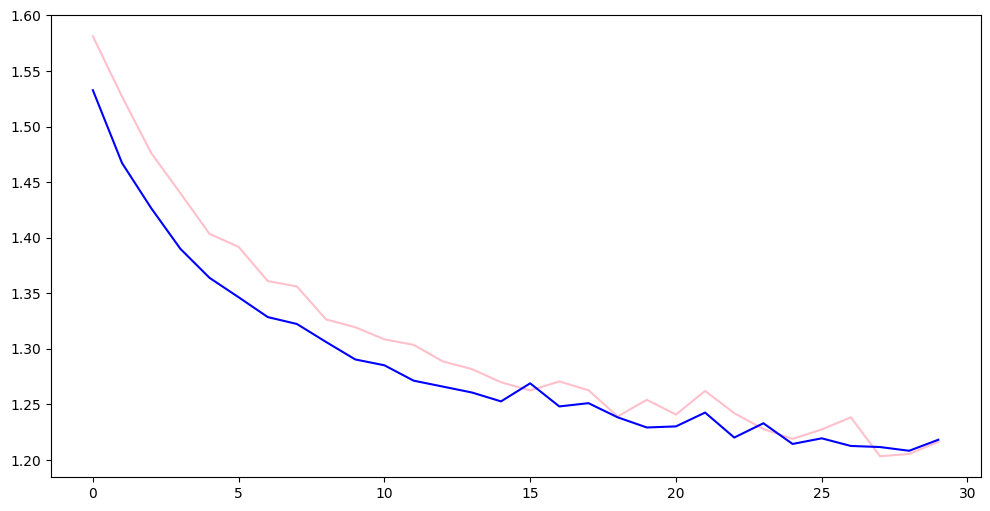

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
epoches = [i for i in range(30)]
plt.plot(epoches, train_losses_audience, color="pink")
plt.plot(epoches, val_losses_audience, color="blue")


In [ ]:
model_audience.load_state_dict(torch.load("best_model_audience.pt"))
model_audience.to(device)
model_audience.eval()
_, _, predictions = evals(X_val_dataloader_audience)
true_labels = []
for batch in X_val_dataloader_audience:
  labels = batch["labels"].cpu().numpy()
  true_labels.extend(labels)
print(classification_report(true_labels, predictions))
print("MAE", mean_absolute_error(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.71      0.69      0.70        49
           1       0.45      0.50      0.47        84
           2       0.40      0.25      0.31        85
           3       0.38      0.45      0.42        88
           4       0.53      0.59      0.56        75

    accuracy                           0.48       381
   macro avg       0.49      0.50      0.49       381
weighted avg       0.47      0.48      0.47       381

MAE 0.6981627296587927


In [ ]:
_, _, predictions_audience = evals(X_text_dataloader_audience)
true_labels_audience = []
for batch in X_text_dataloader_audience:
  labels = batch["labels"].cpu().numpy()
  true_labels_audience.extend(labels)
print(classification_report(true_labels_audience, predictions_audience))
print("MAE", mean_absolute_error(true_labels_audience, predictions_audience))

              precision    recall  f1-score   support

           0       0.15      0.15      0.15       195
           1       0.22      0.23      0.22       337
           2       0.22      0.14      0.17       338
           3       0.23      0.27      0.25       352
           4       0.15      0.16      0.16       298

    accuracy                           0.20      1520
   macro avg       0.19      0.19      0.19      1520
weighted avg       0.20      0.20      0.19      1520

MAE 1.5223684210526316


In [ ]:
X_text_sol = df['Решение кейса'].fillna('').values
y_sol = (df['Проработка решения'].values - 1).astype("int64")

X_train_text_sol, X_test_text_sol, y_train_sol, y_test_sol = train_test_split(
    X_text_sol, y_sol, test_size=0.2, random_state=42, stratify=y_sol
)
X_text_dataset_sol = TextDataset(X_train_text_sol, y_train_sol, tokenizer)
X_val_dataset_sol = TextDataset(X_test_text_sol, y_test_sol, tokenizer)
X_text_dataloader_sol = DataLoader(X_text_dataset_sol, batch_size=16, shuffle=True)
X_val_dataloader_sol = DataLoader(X_val_dataset_sol, batch_size=16, shuffle=False)

In [ ]:
model_sol = BertClassifier(num_classes=5)
model_sol.to(device)
optimizer_sol = torch.optim.AdamW(model_sol.classifier.parameters(), lr=2e-4)
criterion_sol = nn.CrossEntropyLoss()
model = model_sol
model.to(device)
optimizer = optimizer_sol
criterion = criterion_sol


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
y_sol.value_counts()

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [ ]:
best_loss_sol = float("inf")
train_all = 0
val_all = 0
train_losses_sol = []
val_losses_sol = []
for epoch in range(30):
  train_loss = train(X_text_dataloader_sol)
  print(epoch+1)
  print("train_loss=", train_loss)
  train_losses_sol.append(train_loss)
  val_loss, val_acc, predictions = evals(X_val_dataloader_sol)
  print("val_loss=", val_loss)
  print("val_acc=", val_acc)
  val_losses_sol.append(val_loss)
  train_all += train_loss
  val_all+= val_loss
  if val_loss <= best_loss_sol:
    best_loss_sol = val_loss
    torch.save(model_sol.state_dict(), "best_model_sol.pt")
print("avg_train=,", train_all/10)
print("avg_val=,", val_all/10)



1
train_loss= 1.56847799828178
val_loss= 1.5174504419167836
val_acc= 0.2545931758530184
2
train_loss= 1.51153589675301
val_loss= 1.4660152693589528
val_acc= 0.3333333333333333
3
train_loss= 1.4659060578597218
val_loss= 1.4122996230920155
val_acc= 0.3648293963254593
4
train_loss= 1.4475662055768466
val_loss= 1.3838029851516087
val_acc= 0.3805774278215223
5
train_loss= 1.4125778436660767
val_loss= 1.3631561249494553
val_acc= 0.3910761154855643
6
train_loss= 1.3773606325450696
val_loss= 1.3578661978244781
val_acc= 0.3858267716535433
7
train_loss= 1.3783198645240382
val_loss= 1.3379152168830235
val_acc= 0.3963254593175853
8
train_loss= 1.3671840542241147
val_loss= 1.3189619729916255
val_acc= 0.4146981627296588
9
train_loss= 1.3484425695318925
val_loss= 1.3076820472876232
val_acc= 0.4094488188976378
10
train_loss= 1.3414794231715956
val_loss= 1.29691647986571
val_acc= 0.4199475065616798
11
train_loss= 1.3338571611203645
val_loss= 1.3035540878772736
val_acc= 0.4304461942257218
12
train_loss=

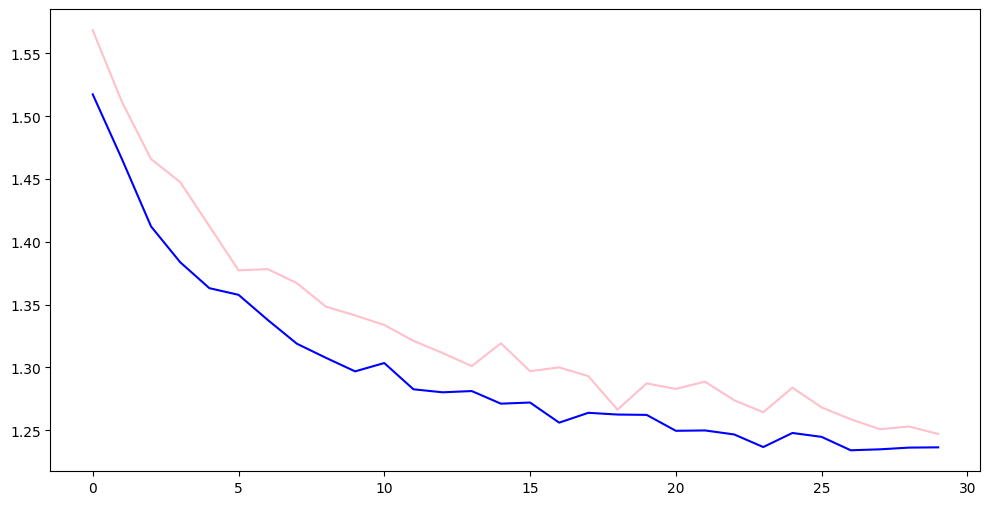

In [ ]:
plt.figure(figsize=(12,6))
epoches = [i for i in range(30)]
plt.plot(epoches, train_losses_sol, color="pink")
plt.plot(epoches, val_losses_sol, color="blue")


In [ ]:
model_sol.load_state_dict(torch.load("best_model_sol.pt"))
model_sol.to(device)
model_sol.eval()
_, _, predictions = evals(X_val_dataloader_sol)
true_labels = []
for batch in X_val_dataloader_sol:
  labels = batch["labels"].cpu().numpy()
  true_labels.extend(labels)
print(classification_report(true_labels, predictions))
print("MAE", mean_absolute_error(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.76      0.57      0.65        49
           1       0.49      0.55      0.52        92
           2       0.48      0.31      0.38        89
           3       0.31      0.32      0.32        81
           4       0.39      0.54      0.45        70

    accuracy                           0.45       381
   macro avg       0.49      0.46      0.46       381
weighted avg       0.47      0.45      0.45       381

MAE 0.7585301837270341


In [ ]:
_, _, predictions_train = evals(X_text_dataloader_sol)
true_labels_train = []
for batch in X_text_dataloader_sol:
  labels = batch["labels"].cpu().numpy()
  true_labels_train.extend(labels)
print(classification_report(true_labels_train, predictions_train))
print("MAE", mean_absolute_error(true_labels_train, predictions_train))

              precision    recall  f1-score   support

           0       0.12      0.09      0.11       194
           1       0.24      0.26      0.25       364
           2       0.25      0.19      0.22       357
           3       0.19      0.19      0.19       325
           4       0.14      0.19      0.17       280

    accuracy                           0.20      1520
   macro avg       0.19      0.19      0.19      1520
weighted avg       0.20      0.20      0.20      1520

MAE 1.525


In [ ]:
model_finance = BertClassifier(num_classes=5)
model_finance.to(device)
optimizer_finance = torch.optim.AdamW(model_finance.classifier.parameters(), lr=2e-4)
criterion_finance = nn.CrossEntropyLoss()
model = model_finance
model.to(device)
optimizer = optimizer_finance
criterion = criterion_finance


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
X_text_finance = df['Решение кейса'].fillna('').values
y_finance = (df['Финансовая модель и метрики'].values - 1).astype("int64")

X_train_text_finance, X_test_text_finance, y_train_finance, y_test_finance = train_test_split(
    X_text_finance, y_finance, test_size=0.2, random_state=42,stratify= y_finance
)
X_text_dataset_finance = TextDataset(X_train_text_finance, y_train_finance, tokenizer)
X_val_dataset_finance = TextDataset(X_test_text_finance, y_test_finance, tokenizer)
X_text_dataloader_finance = DataLoader(X_text_dataset_finance, batch_size=16, shuffle=True)
X_val_dataloader_finance = DataLoader(X_val_dataset_finance, batch_size=16, shuffle=False)

In [ ]:
best_loss_finance = float("inf")
all_train = 0
all_val= 0
train_losses_finance = []
val_losses_finance = []
for epoch in range(30):
  train_loss = train(X_text_dataloader_finance)
  print(epoch+1)
  print("train_loss=", train_loss)
  train_losses_finance.append(train_loss)
  val_loss, val_acc, predictions = evals(X_val_dataloader_finance)
  print("val_loss=", val_loss)
  print("val_acc=", val_acc)
  all_train += train_loss
  all_val += val_loss
  val_losses_finance.append(val_loss)
  if val_loss <= best_loss_finance:
    best_loss_finance = val_loss
    torch.save(model_finance.state_dict(), "best_model_finance.pt")
print("avg_val", all_val / 10)
print("avg_train", all_train/10)

1
train_loss= 1.5699828085146452
val_loss= 1.5198964526255925
val_acc= 0.28346456692913385
2
train_loss= 1.5171778189508538
val_loss= 1.471832349896431
val_acc= 0.3464566929133858
3
train_loss= 1.472284460067749
val_loss= 1.429709975918134
val_acc= 0.3359580052493438
4
train_loss= 1.4388403240003085
val_loss= 1.41200453042984
val_acc= 0.3569553805774278
5
train_loss= 1.409976988089712
val_loss= 1.395969033241272
val_acc= 0.3779527559055118
6
train_loss= 1.4000376375097978
val_loss= 1.3846534540255864
val_acc= 0.3753280839895013
7
train_loss= 1.3768337337594283
val_loss= 1.3845916738112767
val_acc= 0.35958005249343833
8
train_loss= 1.3716859942988346
val_loss= 1.3787095149358113
val_acc= 0.35170603674540685
9
train_loss= 1.3525798446253727
val_loss= 1.36690158645312
val_acc= 0.38320209973753283
10
train_loss= 1.3605180138035824
val_loss= 1.378698542714119
val_acc= 0.33070866141732286
11
train_loss= 1.341421335621884
val_loss= 1.3632817020018895
val_acc= 0.37270341207349084
12
train_loss

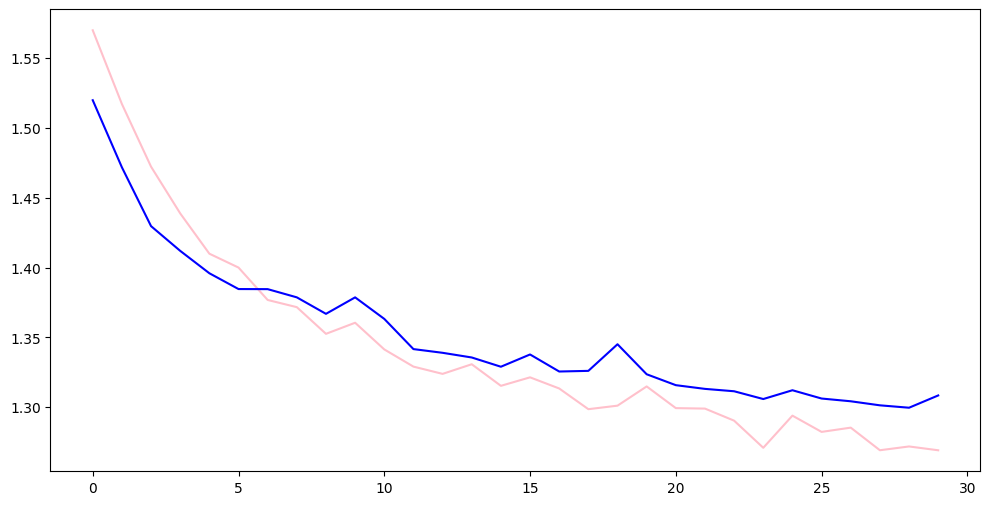

In [ ]:
plt.figure(figsize=(12,6))
epoches = [i for i in range(30)]
plt.plot(epoches, train_losses_finance, color="pink")
plt.plot(epoches, val_losses_finance, color="blue")


In [ ]:
model_finance.load_state_dict(torch.load("best_model_finance.pt"))
model_finance.to(device)
model_finance.eval()
_, _, predictions = evals(X_val_dataloader_finance)
true_labels = []
for batch in X_val_dataloader_finance:
  labels = batch["labels"].cpu().numpy()
  true_labels.extend(labels)
print(classification_report(true_labels, predictions))
print("MAE", mean_absolute_error(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.83      0.64      0.72        53
           1       0.40      0.49      0.44        97
           2       0.39      0.27      0.32        95
           3       0.37      0.65      0.47        84
           4       0.75      0.06      0.11        52

    accuracy                           0.44       381
   macro avg       0.55      0.42      0.41       381
weighted avg       0.50      0.44      0.41       381

MAE 0.7506561679790026


In [ ]:
_, _, predictions_train = evals(X_text_dataloader_finance)
true_labels_train = []
for batch in X_text_dataloader_finance:
  labels = batch["labels"].cpu().numpy()
  true_labels_train.extend(labels)
print(classification_report(true_labels_train, predictions_train))
print("MAE", mean_absolute_error(true_labels_train, predictions_train))

              precision    recall  f1-score   support

           0       0.10      0.09      0.10       210
           1       0.21      0.26      0.23       389
           2       0.27      0.15      0.20       381
           3       0.20      0.37      0.26       335
           4       0.19      0.03      0.05       205

    accuracy                           0.20      1520
   macro avg       0.20      0.18      0.17      1520
weighted avg       0.21      0.20      0.19      1520

MAE 1.368421052631579


In [ ]:
model_risks = BertClassifier(num_classes=5)
model_risks.to(device)
optimizer_risks = torch.optim.AdamW(model_risks.classifier.parameters(), lr=2e-4)
criterion_risks = nn.CrossEntropyLoss()
model = model_risks
model.to(device)
optimizer = optimizer_risks
criterion = criterion_risks


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
X_text_risks = df['Решение кейса'].fillna('').values
y_risks = (df['Анализ рисков'].values - 1).astype("int64")

X_train_text_risks, X_test_text_risks, y_train_risks, y_test_risks = train_test_split(
    X_text_risks, y_risks, test_size=0.2, random_state=42, stratify=y_risks
)
X_text_dataset_risks = TextDataset(X_train_text_risks, y_train_risks, tokenizer)
X_val_dataset_risks = TextDataset(X_test_text_risks, y_test_risks, tokenizer)
X_text_dataloader_risks = DataLoader(X_text_dataset_risks, batch_size=16, shuffle=True)
X_val_dataloader_risks = DataLoader(X_val_dataset_risks, batch_size=16, shuffle=False)

In [ ]:
best_loss_risks = float("inf")
all_val = 0
all_train = 0
train_losses_risks = []
val_losses_risks = []
for epoch in range(30):
  train_loss = train(X_text_dataloader_risks)
  print(epoch+1)
  print("train_loss=", train_loss)
  train_losses_risks.append(train_loss)
  val_loss, val_acc, predictions = evals(X_val_dataloader_risks)
  all_val += val_loss
  all_train += train_loss
  print("val_loss=", val_loss)
  print("val_acc=", val_acc)
  val_losses_risks.append(val_loss)
  if val_loss <= best_loss_risks:
    best_loss_risks = val_loss
    torch.save(model_risks.state_dict(), "best_model_risks.pt")
print("avg_val=", all_val / 10)
print("avg_train=", all_train/10)

1
train_loss= 1.562164504904496
val_loss= 1.5273617853720982
val_acc= 0.2782152230971129
2
train_loss= 1.5014057862131218
val_loss= 1.4775069306294124
val_acc= 0.3543307086614173
3
train_loss= 1.458704786551626
val_loss= 1.4524848908185959
val_acc= 0.3779527559055118
4
train_loss= 1.423179214879086
val_loss= 1.4279864132404327
val_acc= 0.3937007874015748
5
train_loss= 1.4081115308560823
val_loss= 1.4106599936882656
val_acc= 0.3910761154855643
6
train_loss= 1.4005332244069952
val_loss= 1.39970962703228
val_acc= 0.35958005249343833
7
train_loss= 1.3802505192003751
val_loss= 1.3759650389353435
val_acc= 0.3989501312335958
8
train_loss= 1.3684074489693894
val_loss= 1.3810922702153523
val_acc= 0.3700787401574803
9
train_loss= 1.3805695044366937
val_loss= 1.3602785567442577
val_acc= 0.41732283464566927
10
train_loss= 1.3592550566321926
val_loss= 1.3491247047980626
val_acc= 0.4094488188976378
11
train_loss= 1.3472689954858077
val_loss= 1.3509120494127274
val_acc= 0.3963254593175853
12
train_lo

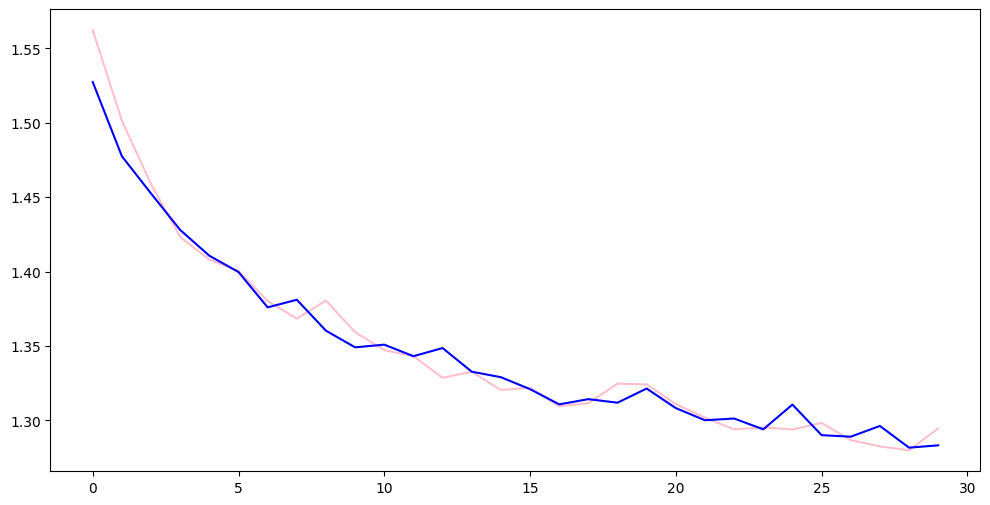

In [ ]:
plt.figure(figsize=(12,6))
epoches = [i for i in range(30)]
plt.plot(epoches, train_losses_risks, color="pink")
plt.plot(epoches, val_losses_risks, color="blue")


In [ ]:
model_risks.load_state_dict(torch.load("best_model_risks.pt"))
model_risks.to(device)
model_risks.eval()
_, _, predictions = evals(X_val_dataloader_risks)
true_labels = []
for batch in X_val_dataloader_risks:
  labels = batch["labels"].cpu().numpy()
  true_labels.extend(labels)
print(classification_report(true_labels, predictions))
print("MAE", mean_absolute_error(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.74      0.50      0.60        62
           1       0.40      0.38      0.39        95
           2       0.36      0.55      0.44        94
           3       0.41      0.51      0.45        79
           4       0.25      0.04      0.07        51

    accuracy                           0.42       381
   macro avg       0.43      0.40      0.39       381
weighted avg       0.43      0.42      0.41       381

MAE 0.7769028871391076


In [ ]:
_, _, predictions_train = evals(X_text_dataloader_risks)
true_labels_train = []
for batch in X_text_dataloader_risks:
  labels = batch["labels"].cpu().numpy()
  true_labels_train.extend(labels)
print(classification_report(true_labels_train, predictions_train))
print("MAE", mean_absolute_error(true_labels_train, predictions_train))

              precision    recall  f1-score   support

           0       0.20      0.15      0.17       248
           1       0.24      0.25      0.25       380
           2       0.24      0.36      0.29       376
           3       0.19      0.21      0.20       313
           4       0.22      0.02      0.04       203

    accuracy                           0.22      1520
   macro avg       0.22      0.20      0.19      1520
weighted avg       0.22      0.22      0.21      1520

MAE 1.2901315789473684


In [ ]:
model_proves = BertClassifier(num_classes=5)
model_proves.to(device)
optimizer_proves = torch.optim.AdamW(model_proves.classifier.parameters(), lr=2e-4)
criterion_proves = nn.CrossEntropyLoss()
model = model_proves
model.to(device)
optimizer = optimizer_proves
criterion = criterion_proves


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
X_text_proves = df['Решение кейса'].fillna('').values
y_proves = (df['Доказательства'].values - 1).astype("int64")

X_train_text_proves, X_test_text_proves, y_train_proves, y_test_proves = train_test_split(
    X_text_proves, y_proves, test_size=0.2, random_state=42, stratify=y_proves
)
X_text_dataset_proves = TextDataset(X_train_text_proves, y_train_proves, tokenizer)
X_val_dataset_proves = TextDataset(X_test_text_proves, y_test_proves, tokenizer)
X_text_dataloader_proves = DataLoader(X_text_dataset_proves, batch_size=16, shuffle=True)
X_val_dataloader_proves = DataLoader(X_val_dataset_proves, batch_size=16, shuffle=False)

In [ ]:
best_loss_proves = float("inf")
all_val = 0
all_train = 0
train_losses_proves = []
val_losses_proves= []
for epoch in range(40):
  train_loss = train(X_text_dataloader_proves)
  print(epoch+1)
  train_losses_proves.append(train_loss)
  print("train_loss=", train_loss)
  val_loss, val_acc, predictions = evals(X_val_dataloader_proves)
  all_val += val_loss
  val_losses_proves.append(val_loss)
  all_train += train_loss
  print("val_loss=", val_loss)
  print("val_acc=", val_acc)
  if val_loss <= best_loss_proves:
    best_loss_proves = val_loss
    torch.save(model_proves.state_dict(), "best_model_proves.pt")
print("avg_val=", all_val/10)
print("avg_train", all_train/10)

1
train_loss= 1.575338834210446
val_loss= 1.5250706722338994
val_acc= 0.29396325459317585
2
train_loss= 1.512820513624894
val_loss= 1.503527839978536
val_acc= 0.32545931758530183
3
train_loss= 1.473492021309702
val_loss= 1.4305403878291447
val_acc= 0.35958005249343833
4
train_loss= 1.4519750193545693
val_loss= 1.424769639968872
val_acc= 0.3779527559055118
5
train_loss= 1.427090122825221
val_loss= 1.395869533220927
val_acc= 0.3779527559055118
6
train_loss= 1.4110064945722882
val_loss= 1.3752005348602931
val_acc= 0.35958005249343833
7
train_loss= 1.3864418481525622
val_loss= 1.3630362451076508
val_acc= 0.4041994750656168
8
train_loss= 1.3725929398285714
val_loss= 1.3469712436199188
val_acc= 0.3989501312335958
9
train_loss= 1.3627684116363525
val_loss= 1.3315913329521816
val_acc= 0.3963254593175853
10
train_loss= 1.3608299493789673
val_loss= 1.3240801841020584
val_acc= 0.3910761154855643
11
train_loss= 1.356337248651605
val_loss= 1.3202897757291794
val_acc= 0.41732283464566927
12
train_lo

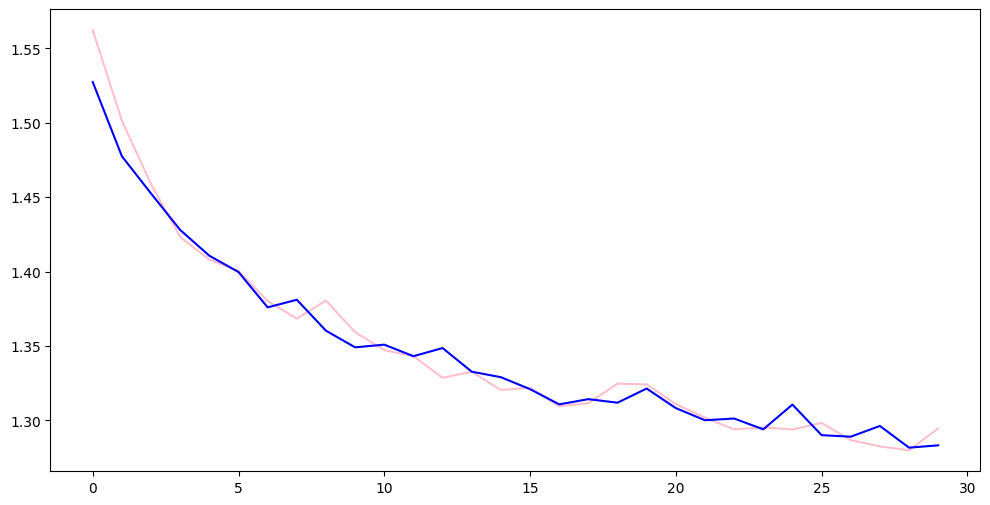

In [ ]:
plt.figure(figsize=(12,6))
epoches = [i for i in range(30)]
plt.plot(epoches, train_losses_risks, color="pink")
plt.plot(epoches, val_losses_risks, color="blue")


In [ ]:
model_proves.load_state_dict(torch.load("best_model_proves.pt"))
model_proves.to(device)
model_proves.eval()
_, _, predictions = evals(X_val_dataloader_proves)
true_labels = []
for batch in X_val_dataloader_proves:
  labels = batch["labels"].cpu().numpy()
  true_labels.extend(labels)
print(classification_report(true_labels, predictions))
print("MAE", mean_absolute_error(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.84      0.57      0.68        63
           1       0.48      0.56      0.52        96
           2       0.34      0.52      0.41        77
           3       0.41      0.37      0.39        84
           4       0.56      0.31      0.40        61

    accuracy                           0.47       381
   macro avg       0.53      0.47      0.48       381
weighted avg       0.51      0.47      0.48       381

MAE 0.7034120734908137


In [ ]:
_, _, predictions_train = evals(X_text_dataloader_proves)
true_labels_train = []
for batch in X_text_dataloader_proves:
  labels = batch["labels"].cpu().numpy()
  true_labels_train.extend(labels)
print(classification_report(true_labels_train, predictions_train))
print("MAE", mean_absolute_error(true_labels_train, predictions_train))

              precision    recall  f1-score   support

           0       0.12      0.10      0.11       249
           1       0.26      0.30      0.28       384
           2       0.22      0.30      0.25       309
           3       0.21      0.19      0.20       336
           4       0.14      0.08      0.10       242

    accuracy                           0.21      1520
   macro avg       0.19      0.19      0.19      1520
weighted avg       0.20      0.21      0.20      1520

MAE 1.4282894736842104


In [ ]:
new_results_df = pd.DataFrame(columns=['Id','Текст_решения','Анализ ЦА','Проработка решения','Финансовая модель и метрики','Анализ рынков','Доказательства','Предсказанная_оценка','Дата'])

In [ ]:
import re

In [ ]:
dec = '''МОЙ ПРОЕКТ

Я хочу сделать бота для школьников. Он будет помогать решать задачи.

Целевая аудитория - школьники. Им это нужно для учебы.

Мое решение - бот в телеграме. Он будет бесплатный. Похожих ботов нет.

Финансы: разработка стоит примерно 500 тысяч рублей. Потом будем зарабатывать на рекламе.

Риски: могут появиться конкуренты. Будем делать лучше.

Доказательства: я сам учился в школе и знаю, что это нужно. Многие мои друзья тоже так думают.'''

In [ ]:
def get_prediction_audience(text):
  model_audience.eval()
  if pd.isna(text) or not isinstance(text, str):
        text = ""
  preds = predicts([text], model_audience, tokenizer, device, label_encoder=None)
  score = int(preds[0])
  return score


In [ ]:
def get_prediction_solution(text):
  model_sol.eval()
  if pd.isna(text) or not isinstance(text, str):
        text = ""
  preds = predicts([text], model_sol, tokenizer, device, label_encoder=None)
  score = int(preds[0])
  return score


In [ ]:
def get_prediction_finance(text):
  model_finance.eval()
  if pd.isna(text) or not isinstance(text, str):
        text = ""
  model.load_state_dict(torch.load("best_model_audience.pt", map_location=device))
  preds = predicts([text], model_finance, tokenizer, device, label_encoder=None)
  score = int(preds[0])
  return score


In [ ]:
def get_prediction_risks(text):
  model_risks.eval()
  if pd.isna(text) or not isinstance(text, str):
        text = ""
  preds = predicts([text], model_risks, tokenizer, device, label_encoder=None)
  score = int(preds[0])
  return score


In [ ]:
def get_prediction_proves(text):
  model_proves.eval()
  if pd.isna(text) or not isinstance(text, str):
        text = ""
  preds = predicts([text], model_proves, tokenizer, device, label_encoder=None)
  score = int(preds[0])
  return score


In [ ]:
df_test_cases['pred_audience'] = df_test_cases['Решение кейса'].apply(get_prediction_audience)
df_test_cases['pred_sol'] = df_test_cases['Решение кейса'].apply(get_prediction_solution)
df_test_cases['pred_finance'] = df_test_cases['Решение кейса'].apply(get_prediction_finance)
df_test_cases['pred_risks'] = df_test_cases['Решение кейса'].apply(get_prediction_risks)
df_test_cases['pred_proves'] = df_test_cases['Решение кейса'].apply(get_prediction_proves)

In [ ]:
df_test_cases['pred_audience']+=1
df_test_cases['pred_finance'] += 1
df_test_cases['pred_risks'] += 1
df_test_cases['pred_sol']+= 1
df_test_cases['pred_proves'] += 1

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)


In [ ]:
#ЦА
accuracy_audience = accuracy_score(df_test_cases['ЦА'], df_test_cases['pred_audience'])
f1micro_audience = f1_score(df_test_cases['ЦА'], df_test_cases['pred_audience'], average='micro')
f1macro_audience = f1_score(df_test_cases['ЦА'], df_test_cases['pred_audience'], average='macro')
print('accuracy_audience= ', accuracy_audience)
print('f1micro_audience= ', f1micro_audience)
print('f1macro_audience= ', f1macro_audience)
print(classification_report(df_test_cases['ЦА'], df_test_cases['pred_audience']))
print("MAE=", mean_absolute_error(df_test_cases['ЦА'], df_test_cases['pred_audience']))

accuracy_audience=  0.3769230769230769
f1micro_audience=  0.3769230769230769
f1macro_audience=  0.3838840271330036
              precision    recall  f1-score   support

           1       0.56      0.39      0.46        23
           2       0.29      0.46      0.35        26
           3       0.40      0.29      0.34        34
           4       0.32      0.36      0.34        22
           5       0.45      0.40      0.43        25

    accuracy                           0.38       130
   macro avg       0.40      0.38      0.38       130
weighted avg       0.40      0.38      0.38       130

MAE= 0.8692307692307693


In [ ]:
accuracy_sol = accuracy_score(df_test_cases['Проработка решения'], df_test_cases['pred_sol'])
f1micro_sol = f1_score(df_test_cases['Проработка решения'], df_test_cases['pred_sol'], average='micro')
f1macro_sol = f1_score(df_test_cases['Проработка решения'], df_test_cases['pred_sol'], average='macro')
print('accuracy_sol= ', accuracy_sol)
print('f1micro_sol= ', f1micro_sol)
print('f1macro_sol= ', f1macro_sol)
print(classification_report(df_test_cases['Проработка решения'], df_test_cases['pred_sol']))
print("MAE=", mean_absolute_error(df_test_cases['Проработка решения'], df_test_cases['pred_sol']))

accuracy_sol=  0.3384615384615385
f1micro_sol=  0.3384615384615385
f1macro_sol=  0.32747034650228823
              precision    recall  f1-score   support

           1       0.55      0.29      0.38        21
           2       0.33      0.53      0.41        32
           3       0.29      0.20      0.24        30
           4       0.42      0.44      0.43        25
           5       0.19      0.18      0.19        22

    accuracy                           0.34       130
   macro avg       0.36      0.33      0.33       130
weighted avg       0.35      0.34      0.33       130

MAE= 0.9230769230769231


In [ ]:
accuracy_finance = accuracy_score(df_test_cases['Финансовая модель'], df_test_cases['pred_finance'])
f1micro_finance = f1_score(df_test_cases['Финансовая модель'], df_test_cases['pred_finance'], average='micro')
f1macro_finance = f1_score(df_test_cases['Финансовая модель'], df_test_cases['pred_finance'], average='macro')
print('accuracy_finance= ', accuracy_finance)
print('f1micro_finance= ', f1micro_finance)
print('f1macro_finance= ', f1macro_finance)
print(classification_report(df_test_cases['Финансовая модель'], df_test_cases['pred_finance']))
print("MAE=", mean_absolute_error(df_test_cases['Финансовая модель'], df_test_cases['pred_finance']))

accuracy_finance=  0.3923076923076923
f1micro_finance=  0.3923076923076923
f1macro_finance=  0.339409606786656
              precision    recall  f1-score   support

           1       0.53      0.39      0.45        23
           2       0.33      0.55      0.41        33
           3       0.43      0.29      0.35        31
           4       0.41      0.62      0.49        24
           5       0.00      0.00      0.00        19

    accuracy                           0.39       130
   macro avg       0.34      0.37      0.34       130
weighted avg       0.35      0.39      0.36       130

MAE= 0.8692307692307693


In [ ]:
accuracy_risks = accuracy_score(df_test_cases['Анализ рынков'], df_test_cases['pred_risks'])
f1micro_risks = f1_score(df_test_cases['Анализ рынков'], df_test_cases['pred_risks'], average='micro')
f1macro_risks = f1_score(df_test_cases['Анализ рынков'], df_test_cases['pred_risks'], average='macro')
print('accuracy_risks= ', accuracy_risks)
print('f1micro_risks= ', f1micro_risks)
print('f1macro_risks= ', f1macro_risks)
print(classification_report(df_test_cases['Анализ рынков'], df_test_cases['pred_risks']))
print("MAE=", mean_absolute_error(df_test_cases['Анализ рынков'], df_test_cases['pred_risks']))

accuracy_risks=  0.27692307692307694
f1micro_risks=  0.27692307692307694
f1macro_risks=  0.22968807425205165
              precision    recall  f1-score   support

           1       0.33      0.19      0.24        26
           2       0.30      0.38      0.33        32
           3       0.22      0.43      0.29        30
           4       0.38      0.22      0.28        27
           5       0.00      0.00      0.00        15

    accuracy                           0.28       130
   macro avg       0.25      0.24      0.23       130
weighted avg       0.27      0.28      0.26       130

MAE= 0.9153846153846154


In [ ]:
accuracy_proves = accuracy_score(df_test_cases['Доказательства'], df_test_cases['pred_proves'])
f1micro_proves = f1_score(df_test_cases['Доказательства'], df_test_cases['pred_proves'], average='micro')
f1macro_proves = f1_score(df_test_cases['Доказательства'], df_test_cases['pred_proves'], average='macro')
print('accuracy_proves= ', accuracy_proves)
print('f1micro_proves= ', f1micro_proves)
print('f1macro_proves= ', f1macro_proves)
print(classification_report(df_test_cases['Доказательства'], df_test_cases['pred_proves']))
print("MAE", mean_absolute_error(df_test_cases['Доказательства'], df_test_cases['pred_proves']))


accuracy_proves=  0.36923076923076925
f1micro_proves=  0.36923076923076925
f1macro_proves=  0.3652060880296174
              precision    recall  f1-score   support

           1       0.44      0.39      0.41        18
           2       0.38      0.42      0.40        38
           3       0.28      0.28      0.28        25
           4       0.24      0.32      0.27        19
           5       0.55      0.40      0.46        30

    accuracy                           0.37       130
   macro avg       0.38      0.36      0.37       130
weighted avg       0.39      0.37      0.37       130

MAE 0.9230769230769231


In [ ]:
sec_dec = """АНАЛИЗ ЦА:
Выделено 3 сегмента:
- Школьники 10-11 класс (45%)
- Студенты (35%)
- Учителя (20%)
Проведен опрос 100 человек.

РЕШЕНИЕ:
Экосистема из 2 продуктов: телеграм бот + дашборд для учителей.
Партнеры: Яндекс.Образование, МФТИ.

ФИНАНСЫ:
CAPEX: 2 млн руб. CAC = 100 руб, LTV = 2000 руб.
Окупаемость: 10 месяцев.

РИСКИ:
Технические (30%) - резервный сервер.

ДОКАЗАТЕЛЬСТВА:
Пилот в школе: NPS = 65.
"""

In [ ]:
df_test_cases["Predict_score"] = round((df_test_cases['pred_audience'] + df_test_cases['pred_sol'] + df_test_cases['pred_finance'] + df_test_cases['pred_risks'] + df_test_cases['pred_proves'])/5)

In [ ]:
print("MAE= ",mean_absolute_error(df_test_cases["Оценка"], df_test_cases["Predict_score"]))

MAE=  0.6615384615384615


In [ ]:
sol_test = """ Я выбрала отрасль кофеен и кофе-точек с собой (кофе на вынос, кофейные киоски, небольшие кофейни на 2–5 столиков). ЦА разделена на две группы. Первая группа — это микробизнес: кофе-байки и кофе-островки с одним сотрудником, работают как ИП или самозанятые. Их проблема в том, что кофейные зерна нужно покупать свежей обжарки каждую неделю, а хорошие обжарщики требуют предоплату 100% за партию от 5 кг, это около 20–30 тысяч рублей единовременно, что для маленькой точки с ежедневной выручкой 5–7 тысяч рублей чувствительно. Вторая группа — это малый бизнес: кофейни с посадочными местами и штатом 2–5 бариста. Их проблема в том, что сезонность спроса сильно различается: зимой продажи выше за счет горячих напитков, а летом люди покупают холодный кофе и чаще берут с собой, но в межсезонье (апрель и октябрь) падение выручки достигает 30%, при этом аренду и зарплату платить надо. Я опиралась на данные исследования «Рынок кофеен России 2024» от компании CoffeeData: рост рынка на 15% за год, количество кофеен достигло 12 тысяч, из них 70% — малый и микробизнес. Также я посмотрел открытую статистику по кофейному рынку на сайте Росстата и несколько статей в профильных телеграм-каналах. В качестве решения я предлагаю продукт «Альфа.Кофе»: кредит на закупку зёрен с отсрочкой первого платежа на 30 дней и с льготным периодом 0% на первые две недели, а также сезонный овердрафт на покрытие аренды в межсезонье на сумму до 100 тысяч рублей. Партнеры — два крупных обжарщика зерна «Coffe Lab» и «Torrefacto», с которыми можно договориться о более выгодных ценах для клиентов банка. Отличие от конкурентов в том, что ни у Сбера, ни у Т-Банка нет специального продукта для кофеен с отсрочкой именно под зерно. По финансам: разработка кредитного продукта обойдется примерно в 6 миллионов рублей, интеграция с партнерами-обжарщиками — в 2 миллиона, маркетинг в кофейных чатах и через конференции бариста — в 2 миллиона. Прогноз: 350 клиентов в первый год, средний доход с клиента — 20 тысяч рублей (за счет процентов по кредиту и эквайринга), выручка — 7 миллионов рублей. Окупаемость — примерно 2,5 года. Риски: конкурентный — другие банки могут запустить похожие продукты; кредитный — часть клиентов может не вернуть деньги, но мы будем проверять по выписке с кофемашины, кто сколько продает. В доказательство я использовал данные CoffeeData и результаты пары интервью с владельцами кофеен в своем городе."""

In [ ]:
predicted_score_audience = get_prediction_audience(sec_dec)
predicted_score_sol = get_prediction_solution(sec_dec)
predicted_score_finance = get_prediction_finance(sec_dec)
predicted_score_risks = get_prediction_risks(sec_dec)
predicted_score_proves = get_prediction_proves(sec_dec)
predicted_score_audience2 = get_prediction_audience(sec_dec)
predicted_score_sol2 = get_prediction_solution(sec_dec)
predicted_score_finance2 = get_prediction_finance(sec_dec)
predicted_score_risks2 = get_prediction_risks(sec_dec)
predicted_score_proves2 = get_prediction_proves(sec_dec)
new_row = pd.DataFrame([{
    'Id': 1,
    'Текст_решения': sec_dec,
    'Анализ ЦА': predicted_score_audience,
    'Проработка решения': predicted_score_sol,
    'Финансовая модель и метрики': predicted_score_finance,
    'Анализ рынков': predicted_score_risks,
    'Доказательства': predicted_score_proves,
    'Предсказанная_оценка': round((predicted_score_audience + predicted_score_sol +
                      predicted_score_finance + predicted_score_risks +
                      predicted_score_proves) / 5),
    'Дата': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}])
new_row2 = pd.DataFrame([{
    'Id': 1,
    'Текст_решения': sec_dec,
    'Анализ ЦА': predicted_score_audience2,
    'Проработка решения': predicted_score_sol2,
    'Финансовая модель и метрики': predicted_score_finance2,
    'Анализ рынков': predicted_score_risks2,
    'Доказательства': predicted_score_proves2,
    'Предсказанная_оценка': round((predicted_score_audience2 + predicted_score_sol2 +
                      predicted_score_finance2 + predicted_score_risks2 +
                      predicted_score_proves2) / 5),
    'Дата': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}])
new_results_df = pd.concat([new_results_df, new_row, new_row2], ignore_index=True)
new_results_df.to_excel("новая_таблица.xlsx", index=False)


/tmp/ipykernel_3876/1005490930.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(score)
/tmp/ipykernel_3876/1097642392.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(score)


In [ ]:
new_results_df

,Id,Текст_решения,Анализ ЦА,Проработка решения,Финансовая модель и метрики,Анализ рынков,Доказательства,Предсказанная_оценка,Дата
0,1,АНАЛИЗ ЦА:\nВыделено 3 сегмента:\n- Школьники ...,5,4,4,4,4,4,2026-06-22 15:34:44
1,1,АНАЛИЗ ЦА:\nВыделено 3 сегмента:\n- Школьники ...,5,4,4,4,4,4,2026-06-22 15:34:44
